In [3]:
# Cell 1: Setup + Load 20 steering users' trajectory data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
os.chdir('/scratch/zhang.yicheng/llm_ft/neural_mechanics_v7')

# Load
df = pd.read_csv('data/trajectories_processed.csv', low_memory=False)
df['date'] = df['date'].astype(str)
df['minutes'] = df['hour'] * 60 + df['min5']

# Load 20 steering users
users = []
with open('steering/user_list.txt') as f:
    for line in f:
        uid, emp = line.strip().split(',')
        users.append({'uid': uid, 'is_employed': int(emp)})
users_df = pd.DataFrame(users)

# Filter to these 20 users
uids = set(users_df['uid'])
sdf = df[df['cuebiq_id'].isin(uids)].copy()

# Add away_from_home flag
sdf['away'] = (sdf['geo_id'] != sdf['home_geo_id']).astype(int)

# Merge employment label
sdf = sdf.merge(users_df.rename(columns={'uid': 'cuebiq_id'}), on='cuebiq_id')

# Filter to non-holiday weekdays only (same as exp2)
sdf_wd = sdf[sdf['is_nonhol_weekday'] == 1].copy()

print(f"Total rows: {len(sdf):,}")
print(f"Weekday rows: {len(sdf_wd):,}")
print(f"Users: {sdf['cuebiq_id'].nunique()} ({users_df['is_employed'].sum()} emp + {(1-users_df['is_employed']).sum()} unemp)")
print(f"Dates: {sdf_wd['date'].nunique()} weekdays")
print(f"Columns: {list(sdf.columns)}")

Total rows: 322,560
Weekday rows: 218,880
Users: 20 (10 emp + 10 unemp)
Dates: 38 weekdays
Columns: ['cuebiq_id', 'date', 'hour', 'min5', 'geo_id', 'time_slot', 'dow', 'is_employed_x', 'home_geo_id', 'is_at_home', 'is_weekend', 'is_weekday', 'is_holiday', 'is_nonhol_weekday', 'in_exp1', 'in_exp2', 'day_name', 'wkday_class', 'is_monday', 'minutes', 'away', 'is_employed_y']


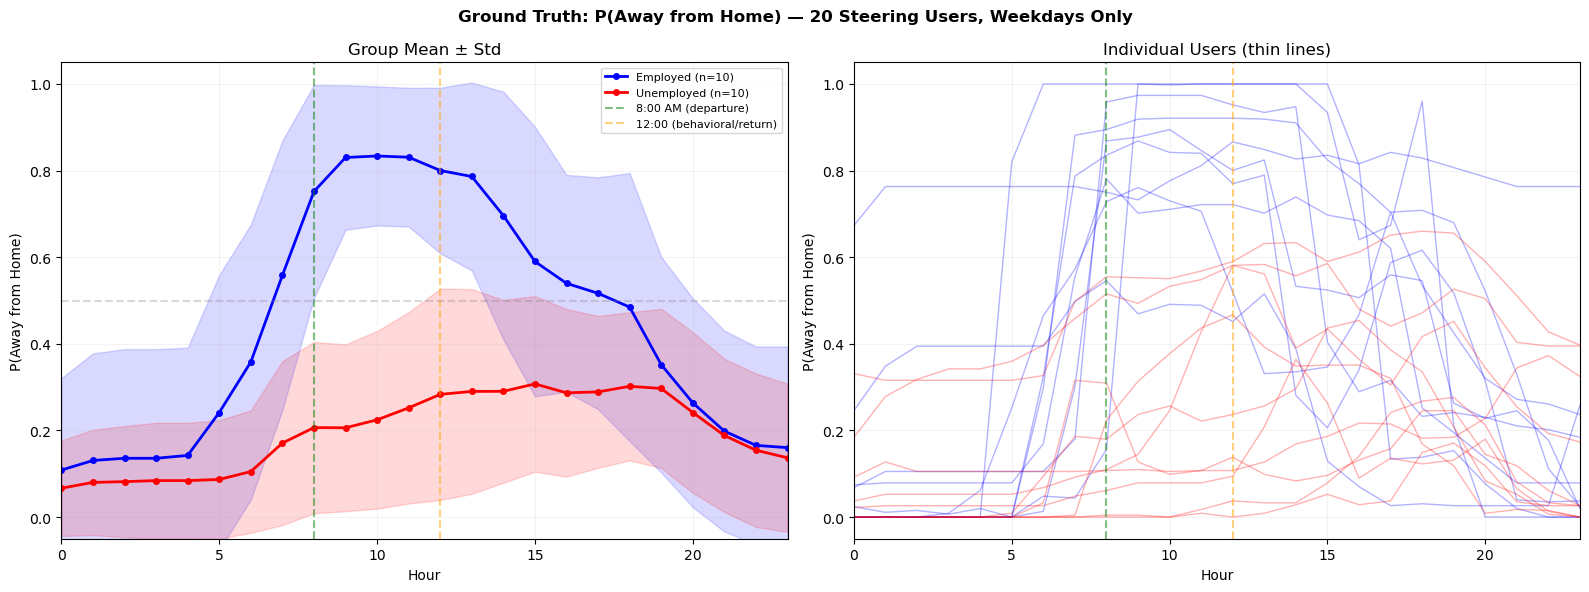

In [4]:
# Cell 2: P(Away from Home) by hour — employed vs unemployed (20 users)
# This is the GROUND TRUTH that all 4 steering prompts probe

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: group mean ± std
for grp, color, label in [(1, 'blue', 'Employed (n=10)'), (0, 'red', 'Unemployed (n=10)')]:
    user_curves = []
    for uid in users_df[users_df['is_employed'] == grp]['uid']:
        udata = sdf_wd[sdf_wd['cuebiq_id'] == uid]
        hourly = udata.groupby('hour')['away'].mean()
        user_curves.append(hourly)
    combined = pd.DataFrame(user_curves).fillna(0)
    mean = combined.mean()
    std = combined.std()
    axes[0].plot(mean.index, mean.values, f'{color[0]}-o', ms=4, lw=2, label=label)
    axes[0].fill_between(mean.index, mean.values - std.values, mean.values + std.values,
                         color=color, alpha=0.15)

axes[0].axvline(8, color='green', ls='--', alpha=0.5, label='8:00 AM (departure)')
axes[0].axvline(12, color='orange', ls='--', alpha=0.5, label='12:00 (behavioral/return)')
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.3)
axes[0].set(xlabel='Hour', ylabel='P(Away from Home)', title='Group Mean ± Std')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.15)
axes[0].set_xlim(0, 23); axes[0].set_ylim(-0.05, 1.05)

# Right: individual user curves
for uid in users_df[users_df['is_employed'] == 1]['uid']:
    h = sdf_wd[sdf_wd['cuebiq_id'] == uid].groupby('hour')['away'].mean()
    axes[1].plot(h.index, h.values, 'b-', alpha=0.3, lw=1)
for uid in users_df[users_df['is_employed'] == 0]['uid']:
    h = sdf_wd[sdf_wd['cuebiq_id'] == uid].groupby('hour')['away'].mean()
    axes[1].plot(h.index, h.values, 'r-', alpha=0.3, lw=1)

axes[1].axvline(8, color='green', ls='--', alpha=0.5)
axes[1].axvline(12, color='orange', ls='--', alpha=0.5)
axes[1].set(xlabel='Hour', ylabel='P(Away from Home)', title='Individual Users (thin lines)')
axes[1].set_xlim(0, 23); axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.15)

plt.suptitle('Ground Truth: P(Away from Home) — 20 Steering Users, Weekdays Only', fontweight='bold')
plt.tight_layout(); plt.show()

Emp  P(away@12): mean=0.813 std=0.171
Unemp P(away@12): mean=0.279 std=0.241
Gap: 0.534


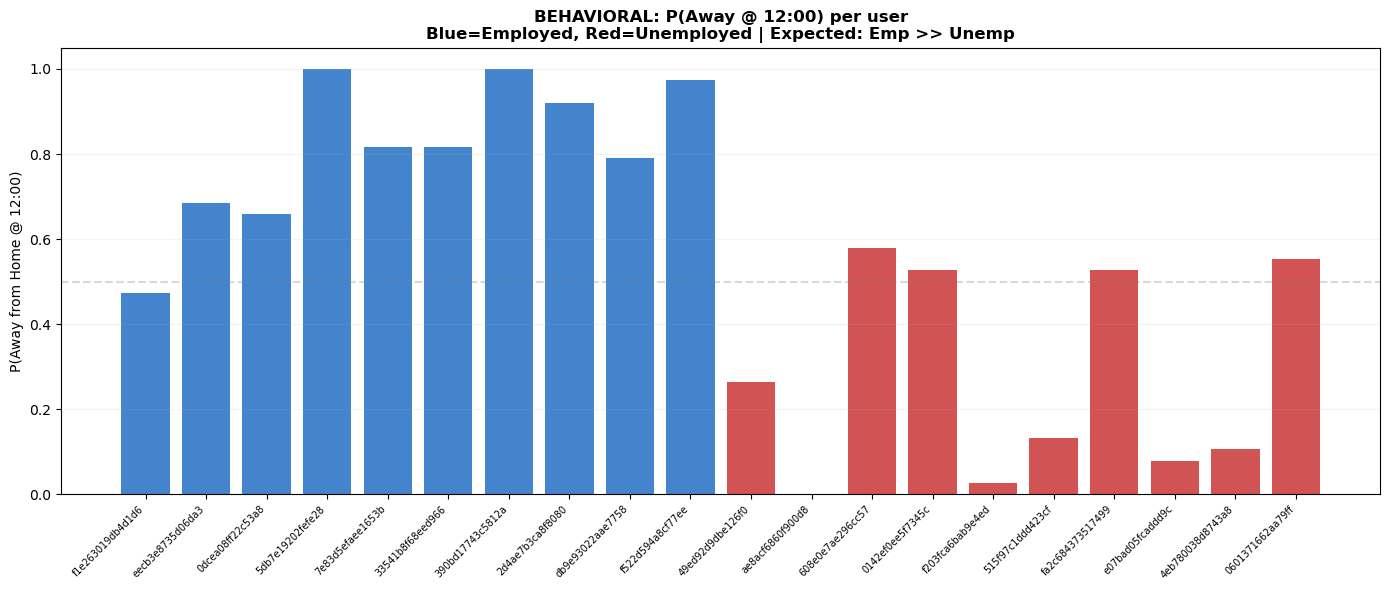

In [5]:
# Cell 3: BEHAVIORAL ground truth — "At 12:00, where is this person?"
# Employed → B (workplace/away), Unemployed → A (home)

results = []
for _, row in users_df.iterrows():
    uid, emp = row['uid'], row['is_employed']
    udata = sdf_wd[(sdf_wd['cuebiq_id'] == uid) & (sdf_wd['hour'] == 12) & (sdf_wd['min5'] == 0)]
    if len(udata) == 0:
        udata = sdf_wd[(sdf_wd['cuebiq_id'] == uid) & (sdf_wd['hour'] == 12)]
    p_away = udata['away'].mean() if len(udata) > 0 else np.nan
    results.append({'uid': uid[:16], 'employed': emp, 'p_away_12': p_away})

bdf = pd.DataFrame(results).sort_values('employed', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1565C0' if e else '#C62828' for e in bdf['employed']]
bars = ax.bar(range(len(bdf)), bdf['p_away_12'], color=colors, alpha=0.8)
ax.set_xticks(range(len(bdf)))
ax.set_xticklabels(bdf['uid'], rotation=45, ha='right', fontsize=7)
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
ax.set_ylabel('P(Away from Home @ 12:00)')
ax.set_title('BEHAVIORAL: P(Away @ 12:00) per user\n'
             'Blue=Employed, Red=Unemployed | Expected: Emp >> Unemp', fontweight='bold')
ax.grid(True, alpha=0.15, axis='y')

# Print stats
emp_vals = bdf[bdf['employed'] == 1]['p_away_12']
une_vals = bdf[bdf['employed'] == 0]['p_away_12']
print(f"Emp  P(away@12): mean={emp_vals.mean():.3f} std={emp_vals.std():.3f}")
print(f"Unemp P(away@12): mean={une_vals.mean():.3f} std={une_vals.std():.3f}")
print(f"Gap: {emp_vals.mean() - une_vals.mean():.3f}")
plt.tight_layout(); plt.show()

Emp  P(left<8AM): mean=0.824 std=0.119
Unemp P(left<8AM): mean=0.250 std=0.251
Gap: 0.574


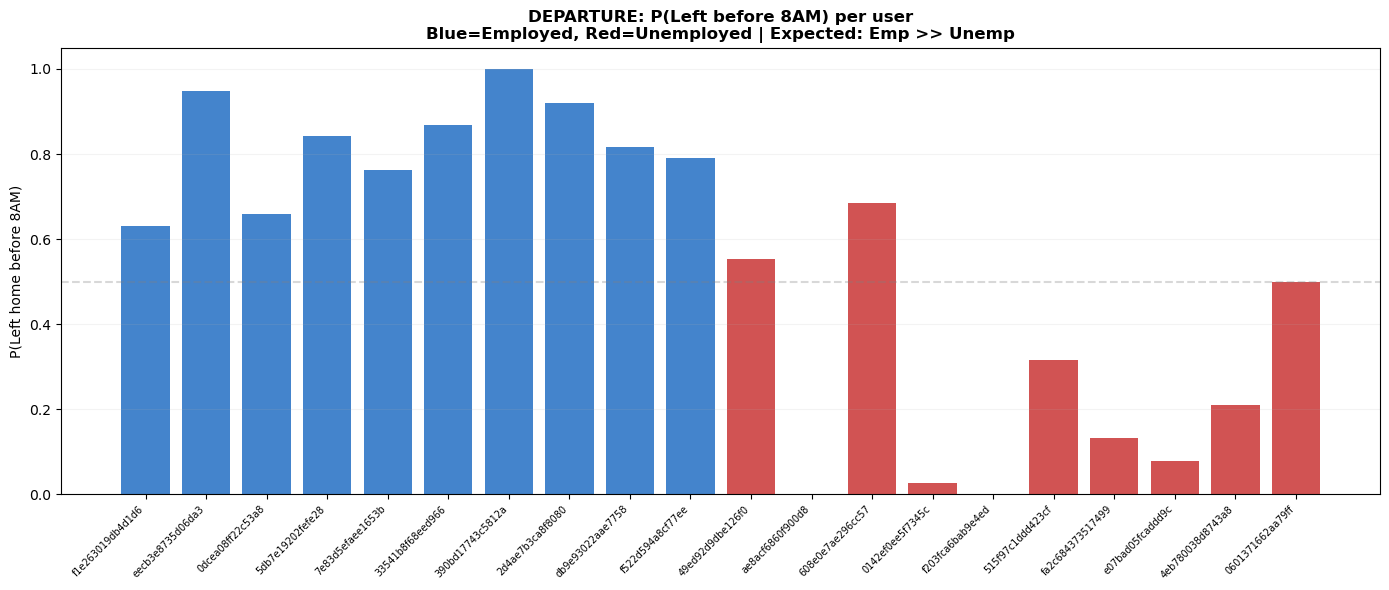

In [6]:
# Cell 4: DEPARTURE ground truth — "Did this person leave home before 8AM?"
# Employed → A (yes left), Unemployed → B (still home)

results = []
for _, row in users_df.iterrows():
    uid, emp = row['uid'], row['is_employed']
    udata = sdf_wd[sdf_wd['cuebiq_id'] == uid]

    # For each day, check if away from home at any point before 8:00
    days = udata['date'].unique()
    left_before_8 = []
    for date in days:
        morning = udata[(udata['date'] == date) & (udata['minutes'] < 480)]  # before 8:00
        if len(morning) > 0:
            left_before_8.append(int(morning['away'].any()))

    p_left = np.mean(left_before_8) if left_before_8 else np.nan
    results.append({'uid': uid[:16], 'employed': emp, 'p_left_before_8': p_left,
                    'n_days': len(left_before_8)})

ddf = pd.DataFrame(results).sort_values('employed', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1565C0' if e else '#C62828' for e in ddf['employed']]
ax.bar(range(len(ddf)), ddf['p_left_before_8'], color=colors, alpha=0.8)
ax.set_xticks(range(len(ddf)))
ax.set_xticklabels(ddf['uid'], rotation=45, ha='right', fontsize=7)
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
ax.set_ylabel('P(Left home before 8AM)')
ax.set_title('DEPARTURE: P(Left before 8AM) per user\n'
             'Blue=Employed, Red=Unemployed | Expected: Emp >> Unemp', fontweight='bold')
ax.grid(True, alpha=0.15, axis='y')

emp_vals = ddf[ddf['employed'] == 1]['p_left_before_8']
une_vals = ddf[ddf['employed'] == 0]['p_left_before_8']
print(f"Emp  P(left<8AM): mean={emp_vals.mean():.3f} std={emp_vals.std():.3f}")
print(f"Unemp P(left<8AM): mean={une_vals.mean():.3f} std={une_vals.std():.3f}")
print(f"Gap: {emp_vals.mean() - une_vals.mean():.3f}")
plt.tight_layout(); plt.show()

Emp  P(still_away@12): mean=0.645 std=0.326
Unemp P(still_away@12): mean=0.250 std=0.228
Gap: 0.395


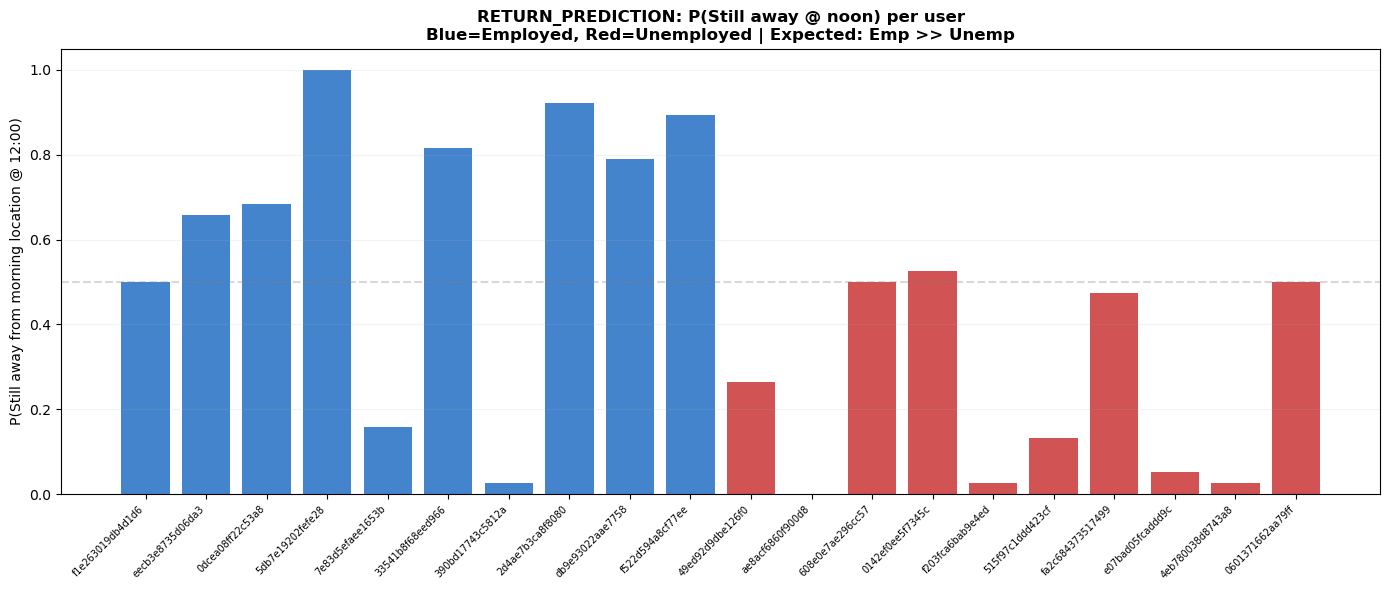

In [7]:
# Cell 5: RETURN_PREDICTION ground truth — "Will this person return to morning location by 12:00?"
# This is essentially: if person left in the morning, are they STILL away at 12:00?
# Employed → B (no, still away), Unemployed → A (yes, back or never left)

results = []
for _, row in users_df.iterrows():
    uid, emp = row['uid'], row['is_employed']
    udata = sdf_wd[sdf_wd['cuebiq_id'] == uid]

    days = udata['date'].unique()
    still_away = []
    for date in days:
        day = udata[udata['date'] == date]
        # Morning location = most common geo_id between 5:00-8:00
        morning = day[(day['minutes'] >= 300) & (day['minutes'] < 480)]
        noon = day[(day['hour'] == 12) & (day['min5'] == 0)]
        if len(noon) == 0:
            noon = day[day['hour'] == 12]
        if len(morning) > 0 and len(noon) > 0:
            morning_loc = morning['geo_id'].mode().iloc[0] if len(morning) > 0 else None
            noon_loc = noon.iloc[0]['geo_id']
            still_away.append(int(noon_loc != morning_loc))

    p_still_away = np.mean(still_away) if still_away else np.nan
    results.append({'uid': uid[:16], 'employed': emp, 'p_still_away': p_still_away,
                    'n_days': len(still_away)})

rdf = pd.DataFrame(results).sort_values('employed', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1565C0' if e else '#C62828' for e in rdf['employed']]
ax.bar(range(len(rdf)), rdf['p_still_away'], color=colors, alpha=0.8)
ax.set_xticks(range(len(rdf)))
ax.set_xticklabels(rdf['uid'], rotation=45, ha='right', fontsize=7)
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
ax.set_ylabel('P(Still away from morning location @ 12:00)')
ax.set_title('RETURN_PREDICTION: P(Still away @ noon) per user\n'
             'Blue=Employed, Red=Unemployed | Expected: Emp >> Unemp', fontweight='bold')
ax.grid(True, alpha=0.15, axis='y')

emp_vals = rdf[rdf['employed'] == 1]['p_still_away']
une_vals = rdf[rdf['employed'] == 0]['p_still_away']
print(f"Emp  P(still_away@12): mean={emp_vals.mean():.3f} std={emp_vals.std():.3f}")
print(f"Unemp P(still_away@12): mean={une_vals.mean():.3f} std={une_vals.std():.3f}")
print(f"Gap: {emp_vals.mean() - une_vals.mean():.3f}")
plt.tight_layout(); plt.show()

In [8]:
# Cell 6: BINARY — no ground truth to check in GPS data
# Binary asks "is this person employed?" — answer depends on model's internal judgment
# Just show the label distribution for reference

print("BINARY prompt: 'Is this person employed?'")
print("This prompt has no GPS-based ground truth — it's a direct judgment.")
print(f"  Employed users: {users_df['is_employed'].sum()}")
print(f"  Unemployed users: {(1-users_df['is_employed']).sum()}")
print(f"  Baseline P(Yes) should differ between groups but Phase 2a showed gap=0.08 only")
print(f"  Binary serves as CONTROL — tests explicit vs implicit knowledge gap")

BINARY prompt: 'Is this person employed?'
This prompt has no GPS-based ground truth — it's a direct judgment.
  Employed users: 10
  Unemployed users: 10
  Baseline P(Yes) should differ between groups but Phase 2a showed gap=0.08 only
  Binary serves as CONTROL — tests explicit vs implicit knowledge gap


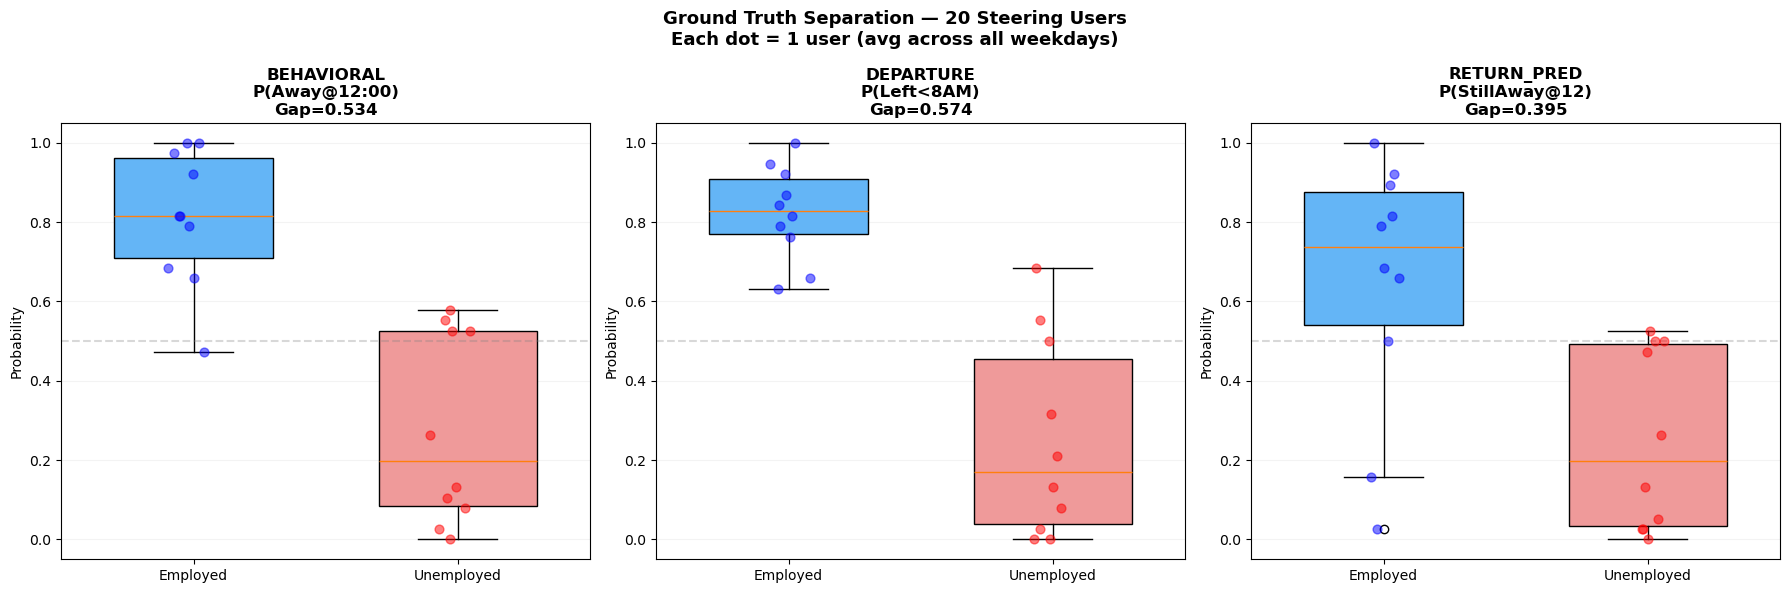

In [9]:
# Cell 7: Summary — all 4 prompts ground truth comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
prompt_data = [
    ('BEHAVIORAL\nP(Away@12:00)', bdf, 'p_away_12'),
    ('DEPARTURE\nP(Left<8AM)', ddf, 'p_left_before_8'),
    ('RETURN_PRED\nP(StillAway@12)', rdf, 'p_still_away'),
]

for ax, (title, data, col) in zip(axes, prompt_data):
    emp = data[data['employed'] == 1][col].dropna()
    une = data[data['employed'] == 0][col].dropna()

    positions = [0, 1]
    bp = ax.boxplot([emp.values, une.values], positions=positions, widths=0.6,
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('#64B5F6')
    bp['boxes'][1].set_facecolor('#EF9A9A')

    # Scatter individual points
    ax.scatter(np.zeros(len(emp)) + np.random.normal(0, 0.05, len(emp)),
               emp.values, c='blue', alpha=0.5, s=40, zorder=5)
    ax.scatter(np.ones(len(une)) + np.random.normal(0, 0.05, len(une)),
               une.values, c='red', alpha=0.5, s=40, zorder=5)

    gap = emp.mean() - une.mean()
    ax.set_xticks(positions)
    ax.set_xticklabels(['Employed', 'Unemployed'])
    ax.set_ylabel('Probability')
    ax.set_title(f'{title}\nGap={gap:.3f}', fontweight='bold')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.15, axis='y')

plt.suptitle('Ground Truth Separation — 20 Steering Users\n'
             'Each dot = 1 user (avg across all weekdays)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [10]:
# Cell 8: Check anomalous users — who breaks the pattern?

print("="*60)
print("ANOMALOUS USERS — employed but behaves unemployed, or vice versa")
print("="*60)

for prompt_name, data, col, expected_emp_high in [
    ('BEHAVIORAL', bdf, 'p_away_12', True),
    ('DEPARTURE', ddf, 'p_left_before_8', True),
    ('RETURN_PRED', rdf, 'p_still_away', True),
]:
    print(f"\n{prompt_name}:")
    for _, row in data.iterrows():
        val = row[col]
        emp = row['employed']
        uid = row['uid']
        # Flag: employed but low value, or unemployed but high value
        if emp == 1 and val < 0.3:
            print(f"  ⚠️  {uid} (EMP) but {col}={val:.3f} — behaves unemployed!")
        elif emp == 0 and val > 0.7:
            print(f"  ⚠️  {uid} (UNEMP) but {col}={val:.3f} — behaves employed!")

ANOMALOUS USERS — employed but behaves unemployed, or vice versa

BEHAVIORAL:

DEPARTURE:

RETURN_PRED:
  ⚠️  7e83d5efaee1653b (EMP) but p_still_away=0.158 — behaves unemployed!
  ⚠️  390bd17743c5812a (EMP) but p_still_away=0.026 — behaves unemployed!


In [1]:
# iteration 8 steering 20 users query code 

In [ ]:
# Cell 1: Setup — load existing 240 users to EXCLUDE from new selection
import os
os.chdir('/scratch/zhang.yicheng/llm_ft/neural_mechanics_v7')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.cloud import bigquery

client = bigquery.Client(project='epistorm-mobility')

# Load existing 240 users (120 emp + 120 unemp) used for probing
existing_users = pd.read_csv('data/users.csv')
existing_uids = set(existing_users['cuebiq_id'].tolist())
print(f"Existing users to exclude: {len(existing_uids)}")
print(f"  Employed: {existing_users['is_employed'].sum()}")
print(f"  Unemployed: {(1-existing_users['is_employed']).sum()}")

In [ ]:
# Cell 2: Query employed users with BOTH home_geo_id and work_geo_id
# These are NEW users not in the probing set

candidates = client.query("""
    SELECT cuebiq_id, num_pings,
           home_geo_id, work_geo_id,
           ST_Y(home_geopoint) as home_lat, ST_X(home_geopoint) as home_lng,
           ST_Y(work_geopoint) as work_lat, ST_X(work_geopoint) as work_lng
    FROM `epistorm-mobility.neural_mechanics.boston_csa_home_users`
    WHERE work_geopoint IS NOT NULL
      AND work_geo_id IS NOT NULL
      AND home_geo_id IS NOT NULL
      AND num_pings >= 500
""").to_dataframe()

print(f"Total employed candidates with home+work geo: {len(candidates):,}")

# Exclude existing 240 users
candidates = candidates[~candidates['cuebiq_id'].isin(existing_uids)]
print(f"After excluding existing 240: {len(candidates):,}")

# Must have home ≠ work (actual commuters, not work-from-home)
candidates = candidates[candidates['home_geo_id'] != candidates['work_geo_id']]
print(f"After excluding home==work: {len(candidates):,}")

candidates.describe()

In [ ]:
# Cell 3: For top candidates, check how many days of data they have
# We need at least 4 weeks (~28 days) of coverage

# Sample 200 candidates to check coverage (avoid querying all 60K+)
np.random.seed(42)
sample_uids = candidates.sample(min(200, len(candidates)))['cuebiq_id'].tolist()
uid_str = ','.join(f"'{u}'" for u in sample_uids)

coverage = client.query(f"""
    SELECT cuebiq_id,
           COUNT(DISTINCT DATE(ts_local)) as n_days,
           MIN(DATE(ts_local)) as first_date,
           MAX(DATE(ts_local)) as last_date,
           COUNT(*) as n_pings
    FROM `epistorm-mobility.neural_mechanics.simple_boston_panel_master_v3_20200101_20200301`
    WHERE cuebiq_id IN ({uid_str})
      AND DATE(ts_local) BETWEEN '2020-01-06' AND '2020-03-01'
    GROUP BY cuebiq_id
""").to_dataframe()

print(f"Coverage stats for {len(coverage)} sampled candidates:")
print(f"  Days: median={coverage['n_days'].median():.0f}, "
      f"min={coverage['n_days'].min()}, max={coverage['n_days'].max()}")
print(f"  Pings: median={coverage['n_pings'].median():.0f}")

# Filter: at least 28 days of data
good_coverage = coverage[coverage['n_days'] >= 28]
print(f"\n  With ≥28 days: {len(good_coverage)} users")

# Merge back with candidates to keep home/work geo
good_candidates = candidates[candidates['cuebiq_id'].isin(good_coverage['cuebiq_id'])]
good_candidates = good_candidates.merge(
    coverage[['cuebiq_id', 'n_days', 'n_pings']], on='cuebiq_id')
print(f"  Good candidates with home+work+coverage: {len(good_candidates)}")

In [2]:
# Cell 4: Sample 30 (oversample from 20) and query full trajectories
np.random.seed(123)
selected_30 = good_candidates.nlargest(30, 'n_pings')  # top 30 by ping count
sel_uids = selected_30['cuebiq_id'].tolist()
uid_str = ','.join(f"'{u}'" for u in sel_uids)

print(f"Querying trajectories for {len(sel_uids)} candidates...")

traj = client.query(f"""
    WITH five_min_visits AS (
        SELECT cuebiq_id, DATE(ts_local) as date,
               EXTRACT(HOUR FROM ts_local) as hour,
               CAST(FLOOR(EXTRACT(MINUTE FROM ts_local) / 5) * 5 AS INT64) as min5,
               EXTRACT(DAYOFWEEK FROM ts_local) as dow,
               geo_id
        FROM `epistorm-mobility.neural_mechanics.simple_boston_panel_master_v3_20200101_20200301`
        WHERE cuebiq_id IN ({uid_str})
          AND DATE(ts_local) BETWEEN '2020-01-06' AND '2020-03-01'
    ),
    ranked AS (
        SELECT *, ROW_NUMBER() OVER (
            PARTITION BY cuebiq_id, date, hour, min5
            ORDER BY geo_id
        ) as rn
        FROM five_min_visits
    )
    SELECT cuebiq_id, date, hour, min5, dow, geo_id
    FROM ranked WHERE rn = 1
""").to_dataframe()

traj['date'] = traj['date'].astype(str)
traj['minutes'] = traj['hour'] * 60 + traj['min5']
print(f"Retrieved {len(traj):,} rows for {traj['cuebiq_id'].nunique()} users")

NameError: name 'np' is not defined

In [ ]:
# Cell 5: Forward-fill to uniform 5-min grid

GRID_MINUTES = np.arange(0, 24 * 60, 5)  # 0, 5, 10, ..., 1435
N_SLOTS = len(GRID_MINUTES)

def forward_fill_grid(ping_minutes, ping_geos, home_geo, grid_minutes):
    """Forward-fill GPS pings onto uniform grid. Default to home_geo."""
    result = []
    ping_idx = 0
    last_geo = home_geo
    for m in grid_minutes:
        while ping_idx < len(ping_minutes) and ping_minutes[ping_idx] <= m:
            last_geo = ping_geos[ping_idx]
            ping_idx += 1
        result.append(last_geo)
    return result

home_lookup = selected_30.set_index('cuebiq_id')['home_geo_id'].to_dict()
work_lookup = selected_30.set_index('cuebiq_id')['work_geo_id'].to_dict()

rows = []
for uid in sel_uids:
    udata = traj[traj['cuebiq_id'] == uid]
    home_geo = home_lookup[uid]
    for date_str, day in udata.groupby('date'):
        day = day.sort_values('minutes')
        geos = forward_fill_grid(day['minutes'].values, day['geo_id'].values,
                                 home_geo, GRID_MINUTES)
        dow = day['dow'].iloc[0]
        for m, g in zip(GRID_MINUTES, geos):
            rows.append({
                'cuebiq_id': uid, 'date': date_str,
                'hour': m // 60, 'min5': m % 60, 'dow': dow,
                'geo_id': g, 'time_slot': f"{m//60:02d}:{m%60:02d}",
            })

sdf = pd.DataFrame(rows)
sdf['home_geo_id'] = sdf['cuebiq_id'].map(home_lookup)
sdf['work_geo_id'] = sdf['cuebiq_id'].map(work_lookup)
sdf['is_at_home'] = (sdf['geo_id'] == sdf['home_geo_id']).astype(int)
sdf['is_at_work'] = (sdf['geo_id'] == sdf['work_geo_id']).astype(int)
sdf['minutes'] = sdf['hour'] * 60 + sdf['min5']

# Weekend flag (BQ: 1=Sun, 7=Sat)
sdf['is_weekend'] = sdf['dow'].isin([1, 7]).astype(int)
sdf['is_weekday'] = 1 - sdf['is_weekend']

print(f"Grid data: {len(sdf):,} rows, {sdf['cuebiq_id'].nunique()} users")
print(f"  Days/user: {sdf.groupby('cuebiq_id')['date'].nunique().median():.0f}")
print(f"  Slots/user/day: {N_SLOTS}")

In [ ]:
# Cell 6: EDA — Commute pattern validation
# A "typical" employed user should show: leave home AM, arrive work, return home PM

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

wd = sdf[sdf['is_weekday'] == 1]

# Top-left: Mean P(at_work) per hour
ax = axes[0, 0]
for uid in sel_uids:
    u = wd[wd['cuebiq_id'] == uid]
    h = u.groupby('hour')['is_at_work'].mean()
    ax.plot(h.index, h.values, 'b-', alpha=0.2, lw=0.8)
overall = wd.groupby('hour')['is_at_work'].mean()
ax.plot(overall.index, overall.values, 'b-o', lw=3, ms=4, label='Mean', zorder=10)
ax.set(xlabel='Hour', ylabel='P(at work)', title='Weekday P(at work)')
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
ax.legend(); ax.grid(True, alpha=0.15); ax.set_ylim(-0.05, 1.05)

# Top-right: Mean P(at_home) per hour
ax = axes[0, 1]
for uid in sel_uids:
    u = wd[wd['cuebiq_id'] == uid]
    h = u.groupby('hour')['is_at_home'].mean()
    ax.plot(h.index, h.values, 'r-', alpha=0.2, lw=0.8)
overall = wd.groupby('hour')['is_at_home'].mean()
ax.plot(overall.index, overall.values, 'r-o', lw=3, ms=4, label='Mean', zorder=10)
ax.set(xlabel='Hour', ylabel='P(at home)', title='Weekday P(at home)')
ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
ax.legend(); ax.grid(True, alpha=0.15); ax.set_ylim(-0.05, 1.05)

# Bottom-left: Per-user fraction_work (weekday 9AM-5PM)
ax = axes[1, 0]
work_hours = wd[(wd['hour'] >= 9) & (wd['hour'] < 17)]
user_frac_work = work_hours.groupby('cuebiq_id')['is_at_work'].mean().sort_values(ascending=False)
ax.bar(range(len(user_frac_work)), user_frac_work.values, color='steelblue', alpha=0.8)
ax.axhline(0.3, color='red', ls='--', label='Threshold 0.3')
ax.set(xlabel='User (sorted)', ylabel='Fraction at work (9-17h)',
       title='Per-user weekday work fraction')
ax.legend(); ax.grid(True, alpha=0.15, axis='y')

# Bottom-right: Per-user fraction_home (weekday 9AM-5PM)
ax = axes[1, 1]
user_frac_home = work_hours.groupby('cuebiq_id')['is_at_home'].mean().sort_values(ascending=False)
ax.bar(range(len(user_frac_home)), user_frac_home.values, color='coral', alpha=0.8)
ax.axhline(0.7, color='red', ls='--', label='Threshold 0.7 (WFH?)')
ax.set(xlabel='User (sorted)', ylabel='Fraction at home (9-17h)',
       title='Per-user weekday home fraction')
ax.legend(); ax.grid(True, alpha=0.15, axis='y')

plt.suptitle('Steering User EDA — Commute Pattern Validation (30 candidates)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Cell 7: Flag outliers — remove users who don't commute

# "Typical employed" criteria (weekday 9-17h):
#   fraction_at_work > 0.3  (spends >30% of work hours at work)
#   fraction_at_home < 0.7  (doesn't stay home >70%)

work_hours = wd[(wd['hour'] >= 9) & (wd['hour'] < 17)]
user_stats = work_hours.groupby('cuebiq_id').agg(
    frac_work=('is_at_work', 'mean'),
    frac_home=('is_at_home', 'mean'),
    n_days=('date', 'nunique'),
).reset_index()

# Merge home/work lookup
user_stats['home_geo_id'] = user_stats['cuebiq_id'].map(home_lookup)
user_stats['work_geo_id'] = user_stats['cuebiq_id'].map(work_lookup)

# Flag
user_stats['is_typical'] = (
    (user_stats['frac_work'] > 0.3) &
    (user_stats['frac_home'] < 0.7) &
    (user_stats['n_days'] >= 28)
)

print("User screening:")
print(f"  Total: {len(user_stats)}")
print(f"  Typical commuters: {user_stats['is_typical'].sum()}")
print(f"  Outliers:")

outliers = user_stats[~user_stats['is_typical']]
for _, row in outliers.iterrows():
    reasons = []
    if row['frac_work'] <= 0.3: reasons.append(f"low work frac={row['frac_work']:.2f}")
    if row['frac_home'] >= 0.7: reasons.append(f"high home frac={row['frac_home']:.2f}")
    if row['n_days'] < 28: reasons.append(f"low days={row['n_days']}")
    print(f"    {row['cuebiq_id'][:16]}: {', '.join(reasons)}")

# Select final 20
typical = user_stats[user_stats['is_typical']].nlargest(20, 'frac_work')
print(f"\nFinal 20 selected (highest work fraction among typical):")
for _, row in typical.iterrows():
    print(f"  {row['cuebiq_id'][:16]}: work={row['frac_work']:.2f} "
          f"home={row['frac_home']:.2f} days={row['n_days']}")

In [ ]:
# Cell 8: Save to data/ for steering pipeline

final_uids = typical['cuebiq_id'].tolist()

# Save user metadata
steering_users = selected_30[selected_30['cuebiq_id'].isin(final_uids)].copy()
steering_users = steering_users.merge(
    user_stats[['cuebiq_id', 'frac_work', 'frac_home', 'n_days']],
    on='cuebiq_id'
)
steering_users.to_csv('data/steering_users_v2.csv', index=False)
print(f"Saved: data/steering_users_v2.csv ({len(steering_users)} users)")

# Save trajectory data (forward-filled, 5-min grid)
steering_traj = sdf[sdf['cuebiq_id'].isin(final_uids)].copy()
steering_traj.to_csv('data/steering_trajectories_v2.csv', index=False)
print(f"Saved: data/steering_trajectories_v2.csv ({len(steering_traj):,} rows)")

# Save user list (same format as steering/user_list.txt)
with open('steering/user_list_v2.txt', 'w') as f:
    for uid in final_uids:
        f.write(f"{uid},1\n")  # all employed
print(f"Saved: steering/user_list_v2.txt ({len(final_uids)} users)")

# Verify no overlap with existing 240
overlap = set(final_uids) & existing_uids
print(f"\nOverlap with existing 240 probing users: {len(overlap)}")
assert len(overlap) == 0, "OVERLAP DETECTED — must re-select!"
print("No overlap confirmed.")

In [ ]:
# Cell 9: Visualize final 20 users — weekday vs weekend comparison

steer_wd = steering_traj[steering_traj['is_weekday'] == 1]
steer_we = steering_traj[steering_traj['is_weekend'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Weekday
ax = axes[0]
for uid in final_uids:
    u = steer_wd[steer_wd['cuebiq_id'] == uid]
    h = u.groupby('hour')['is_at_work'].mean()
    ax.plot(h.index, h.values, 'b-', alpha=0.3, lw=1)
overall = steer_wd.groupby('hour')['is_at_work'].mean()
ax.plot(overall.index, overall.values, 'b-o', lw=3, label=f'Mean (n={len(final_uids)})', zorder=10)
ax.set(xlabel='Hour', ylabel='P(at work)', title='WEEKDAY — P(at work)')
ax.grid(True, alpha=0.15); ax.legend(); ax.set_ylim(-0.05, 1.05)

# Weekend
ax = axes[1]
for uid in final_uids:
    u = steer_we[steer_we['cuebiq_id'] == uid]
    h = u.groupby('hour')['is_at_work'].mean()
    ax.plot(h.index, h.values, 'r-', alpha=0.3, lw=1)
overall = steer_we.groupby('hour')['is_at_work'].mean()
ax.plot(overall.index, overall.values, 'r-o', lw=3, label=f'Mean (n={len(final_uids)})', zorder=10)
ax.set(xlabel='Hour', ylabel='P(at work)', title='WEEKEND — P(at work)')
ax.grid(True, alpha=0.15); ax.legend(); ax.set_ylim(-0.05, 1.05)

plt.suptitle('Final 20 Steering Users — Weekday vs Weekend Work Pattern\n'
             'Expected: high weekday work, low weekend work',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()